# Practical Exam - Coffee Shops
This is a practice run to the DataCamp Certification practical exam.

## Background
* Java June is a company that owns coffee shops in a number of locations in Europe
* The company knows that stores with more reviews typically get more new customers. This is because new customers consider the number of reviews when picking between two shops
* They want to get more insight what leads to more reviews
* They are also interested in whether there is a link between the number of revies and rating
* They want a report to answer these questions

## Tasks
These are the tasks required for passing the test
1. For every column in the data:
	1. State whether the values match the description given in the table above.
	2. State the number of missing values in the column
	3. Describe what you did to make values match the description if they did notmatch.
2. Create a visualization that shows how many stores were given each rating. Use the visualization to:
	1. State which category of the variable rating has the most number of observations
	2. Explain whether the observations are balanced across categories
3. Describe the distribution of the number of reviews. Your answer must include a visualization that shows the distribution.
4. Describe the relationship between number of reviews and rating. Your answer must include a visualization to demonstrate the relationship.
5. The business wants to predict the number of reviews a store will get using the data provided. State the type of machine learning problem that this is (regression/classification/clustering).
6. Fit a baseline model to predict the number of reviews a store will get using the data provided. **You must include your code.**
7. Fit a comparison model to predict the number of reviews a store will get using the data provided. **You must include your code.**
8. Explain why you chose the two models used in parts 6 and 7.
9. Compare the performance of the two models used in parts 6 and 7, using any method suitable for the type of model. **You must include your code.**
10. Explain which model performs better and why.

## Data
The dataset contains information about coffe shops owned by Java June company

| Column Name | Criteria |
| --- | --- |
| Region | **Nominal** - Where the store is located. One of 10 possible regions (A to J). Missing values should be replaced with "Unknown". |
| Place name | **Nominal** - The name of the store. Missing values should be replaced with "Unknown". |
| Place type | **Nominal** - The type of coffee shop. One of "Coffee shop", "Cafe", "Espresso bar", and "Others". Missing values should be replaced with "Unknown". |
| Rating | **Ordinal** - Average rating of the store from reviews. On a 5 point scale. Missing values should be replaced with 0. |
| Reviews | **Nominal** - The number of reviews given to the store. Missing values should be replaced with the overall median number. |
| Price | **Ordinal** - The price range of products in the store. One of "\$", "\$\$", or "\$\$\$". Missing values should be replaced with "Unknown". |
| Delivery Option | **Nominal** - If delivery is available. Either True or False. Missing values should be replaced with False. |
| Dine in Option | **Nominal** - If dine in is available. Either True or False. Missing values should be replaced with False. |
| Takeaway Option | **Nominal** - If take away is available. Either True or False. Missing values should be replaced with False. |



# 1. Read coffee.csv file and clean the columns

In [1]:
#Importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
#Reading csv file
coffee = pd.read_csv('coffee.csv')

#Check info
display(coffee.info())
display(coffee.isna().sum())
coffee.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Region           200 non-null    object 
 1   Place name       200 non-null    object 
 2   Place type       200 non-null    object 
 3   Rating           198 non-null    float64
 4   Reviews          198 non-null    float64
 5   Price            200 non-null    object 
 6   Delivery option  200 non-null    bool   
 7   Dine in option   140 non-null    object 
 8   Takeout option   144 non-null    object 
dtypes: bool(1), float64(2), object(6)
memory usage: 12.8+ KB


None

Region              0
Place name          0
Place type          0
Rating              2
Reviews             2
Price               0
Delivery option     0
Dine in option     60
Takeout option     56
dtype: int64

,Region,Place name,Place type,Rating,Reviews,Price,Delivery option,Dine in option,Takeout option
0,C,Dim Kavu,Others,4.6,206.0,$$,False,NaN,NaN
1,C,Коферум,Cafe,5.0,24.0,$$,False,NaN,True
2,C,Кофейня Світ Чаю,Coffee shop,5.0,11.0,$$,False,NaN,True
3,C,Кофейня Starcoff,Coffee shop,4.4,331.0,$$,False,True,True
4,C,"Кофейня ""Friend Zone""",Coffee shop,5.0,12.0,$$,False,True,True


## Data transformation
From the data description and data evaluation, it is possible to consider changing these columns data types as follow:
* Region - replace with `category` type
* Place Type - replace with `category` type
* Price - replace with `category` type
* Dine in option - replace with `bool` type, replacing as instructed
* Takeout option - replace with `bool` type, replacing as instructed

In [3]:
#Replace takeout and dinein null with False and dtype to bool
bool_cols = ['Dine in option','Takeout option']

for col in bool_cols:
    coffee[col] = coffee[col].fillna(False)
    coffee[col] = coffee[col].astype('bool')

In [4]:
#Replace Rating
coffee['Rating'] = coffee['Rating'].fillna(0)

#Replace Reviews
coffee['Reviews'] = coffee['Reviews'].fillna(coffee['Reviews'].median())

In [5]:
#Set categorical columns dtype to category
cat_cols = ['Region', 'Place type','Price']

for col in cat_cols:
    coffee[col] = coffee[col].astype('category')
coffee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Region           200 non-null    category
 1   Place name       200 non-null    object  
 2   Place type       200 non-null    category
 3   Rating           200 non-null    float64 
 4   Reviews          200 non-null    float64 
 5   Price            200 non-null    category
 6   Delivery option  200 non-null    bool    
 7   Dine in option   200 non-null    bool    
 8   Takeout option   200 non-null    bool    
dtypes: bool(3), category(3), float64(2), object(1)
memory usage: 6.7+ KB


## Cleaned data
As the `coffee.info()` method output has shown, the data now matches the description presented above. All of the rows now have no missing values and fit to the data type they should.

### Further manipulation
More steps will be used in order to prepare the data to use it in machine learning models, for now, they will remain as they are for easier understanding of the analysis.

# 2. Reviews Visual Analysis

## Rating
This section will focus on checking how many stores were given each rating.

In [6]:
#Setting plotting params
sns.set()
sns.set_style('whitegrid')
sns.set_context('notebook')
sns.set_palette('colorblind')

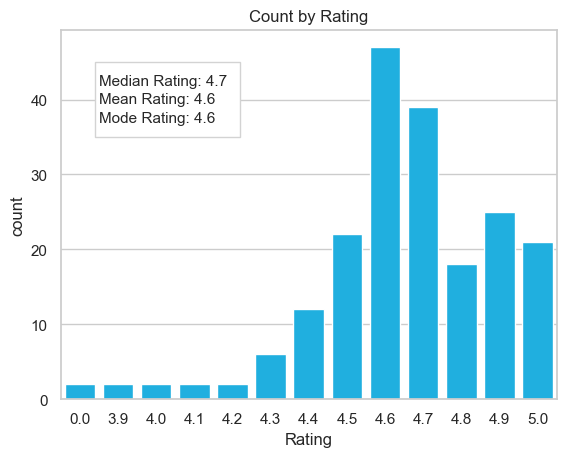

In [7]:
#Plot the data
hist = sns.countplot(data=coffee, x='Rating', color='deepskyblue').set(title='Count by Rating')

#Make ajustments and annotation
plt.annotate('Median Rating: {:.2}'.format(coffee['Rating'].median()),
             xy=(0.5,42.5),
             ha='left',
             va='center',
            fontsize=11)
plt.annotate('Mean Rating: {:.2}'.format(coffee['Rating'].mean()),
             xy=(0.5,40),
             ha='left',
             va='center',
            fontsize=11
            )
plt.annotate('Mode Rating: {:.2}'.format(coffee['Rating'].mode()[0]),
             xy=(0.5,37.5),
             ha='left',
             va='center',
             fontsize=11
            )

#Backgroud rectangle
rect = mpatches.Rectangle((0.4,35),3.8, 10,
                         fill=True,
                         color='white',
                          ec='lightgray',
                         linewidth=1)
plt.gca().add_patch(rect)
plt.show()

## Results
With the countplot shown above, and the Rating measurements of central tendency shown in the plot, it is possible to conclude that the variable rating is not balanced across the possible values

### The plot
The plot is a countplot and it shows values from 0.0 up to 5.0, the 0.0 values were the ones with missing values for the Rating column. Apart from the 0.0 values, there are only values equal or greater than 3.9, which means the distribution is not even across all possible values

The plot has shown that the rating with most occurrences is 4.6.

### Measurements
The plot also included the _median_, _mean_ and _mode_ of the Rating column of the coffee DataFrame. They can be used to support the conclusions made with the plot. The most appropriate measurement in this case is _mode_, which has a value of 4.6, being that the most common and most observed value in the series.

Both the median and mean can be used to show that there is not an even distribution of the rating values. Since all three of the measurements are similar, most values are close to the 4.6 rating value

## Number of reviews
This section will focus on analysing the number of ratings distribution

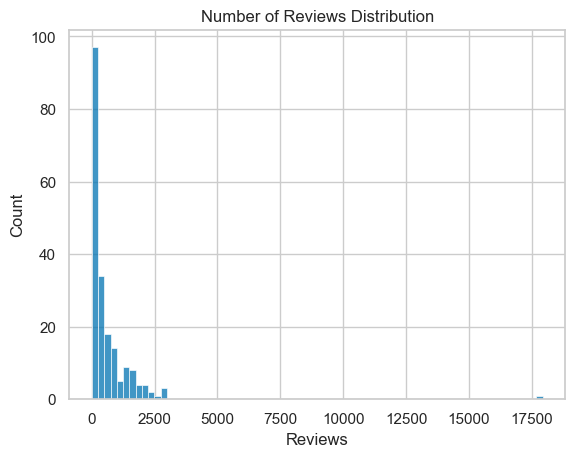

In [8]:
hist_num = sns.histplot(data=coffee, x='Reviews').set(title='Number of Reviews Distribution')

plt.show()

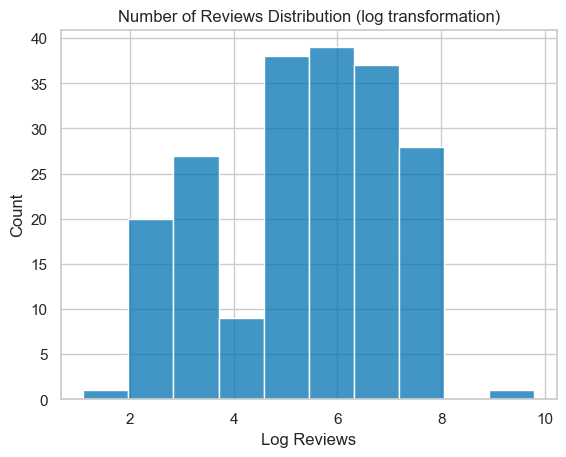

In [9]:
log_hist_num = sns.histplot(data=coffee, x=np.log(coffee['Reviews']))\
.set(title='Number of Reviews Distribution (log transformation)')
plt.xlabel('Log Reviews')
plt.show()

There is an outlier greater than 17500 in the first plot. Applying log transformation to the x axis shows a distribution more similar to a normal one

## Task 4

[Text(0.5, 1.0, 'Reviews and Rating Relationship')]

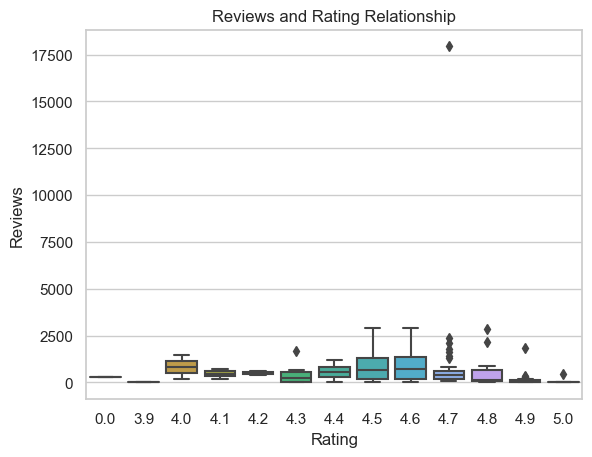

In [10]:
sns.boxplot(data=coffee, x='Rating', y='Reviews').set(title='Reviews and Rating Relationship')

In [11]:
outlier = coffee['Reviews'] == (coffee['Reviews'].max())
coffee_in = coffee[~outlier]

[Text(0.5, 1.0, 'Reviews and Rating Relationship (outlier disconsidered)')]

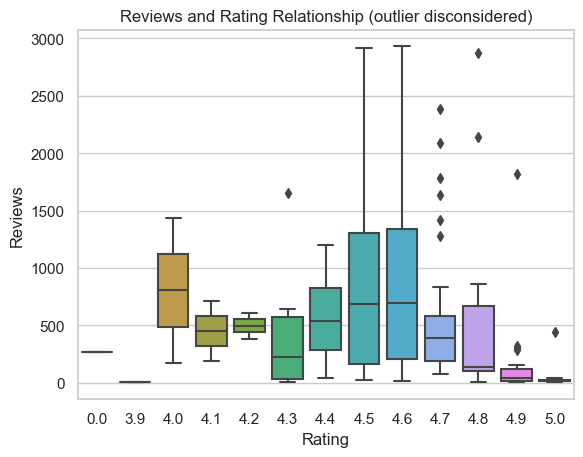

In [12]:
sns.boxplot(data=coffee_in, x='Rating', y='Reviews').set(title='Reviews and Rating Relationship (outlier disconsidered)')

## 3. ML Modeling
This section will focus on manipulating and preparing data for the model fitting. It is necessary to follow these steps:
1. Drop `Place name` column because it contains only unique values, which should not be used as a feature
2. Remove the Reviews 17500 outlier
3. Split data into features and target variable
4. Get dummies from `'category'` columns
5. Apply log scale to the target variable

In [13]:
#Drop place name
if 'Place name' in coffee.columns:
    coffee = coffee.drop('Place name', axis=1)

#Drop outlier
while coffee['Reviews'].max() > 10000:
    outlier = coffee['Reviews'] == (coffee['Reviews'].max())
    coffee = coffee[~outlier]

In [14]:
#Setting characteristics of split
categorical = ['Region', 'Place type','Price']
features = coffee.drop('Reviews', axis=1)

#Splitting data into features and target
y = np.log(coffee['Reviews'])
X = pd.get_dummies(features, columns=categorical, drop_first=True)

In [15]:
#Importing packages for ML models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [16]:
#Splitting into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2710)

### Task 6
Base Model - Linear Regression

In [17]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred_linreg = linreg.predict(X_test)

### Task 7
Comparisson Model - Random Forest Regression

In [18]:
randforest = RandomForestRegressor()
randforest.fit(X_train, y_train)
y_pred_randforest = randforest.predict(X_test)

### Task 8
I am choosing the **Linear Regression** model as a baseline model because it is simple and efficient to train and interpret. The comparison model I am choosing is the **Random Forest** model because it can capture more complex relationship between the input features and the target variables.

### Task 9
I am choosing root **mean squared error (RMSE)** to evaluate the model because it is commonly used and easy to interpret because it is using the same unit as the target variable. Root mean squared error is the roof of the average squared distance between the predicted values and true values.

Note - _Both_ `y_test` _and_ `y_pred` _need no be passed to the_ `np.exp` _function due to the transformation made while splitting the dataset_

#### Evaluating Linear Regression Model

In [19]:
mse_lin = mean_squared_error(np.exp(y_test),np.exp(y_pred_linreg))
np.sqrt(mse_lin)

601.4950601484448

#### Evaluating Random Forest Model

In [20]:
mse_rand = mean_squared_error(np.exp(y_test),np.exp(y_pred_randforest))
np.sqrt(mse_rand)

544.434853733412

## Task 10
A smaller RMSE value indicates the model has smaller errors in prediction.

Therefore, **Random Forest model** is performing better at predicting the number of reviews a store will get than Linear Regression Model based on this metric.